<a href="https://colab.research.google.com/github/Anudeepkonka/Used-Car-Market-Analysis-Insights/blob/main/Used_Car_Market_Analysis_%26_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("/content/Used_Car_Price_Prediction.csv")

print("Shape:", df.shape)
print(df.head())
df.info()

# ------------------------------------------------
# DUPLICATES
# ------------------------------------------------

print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

# ------------------------------------------------
# MISSING VALUES
# ------------------------------------------------

missing = df.isnull().sum().sort_values(ascending=False)

print("\nMissing values:")
print(missing[missing > 0])

# ------------------------------------------------
# NUMERIC CONVERSION
# ------------------------------------------------

numeric_columns = [
    "yr_mfr",
    "kms_run",
    "sale_price",
    "original_price",
    "total_owners"
]

for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

# ------------------------------------------------
# REMOVE INVALID PRICES
# ------------------------------------------------

df = df[df["sale_price"] > 0]

# ------------------------------------------------
# REMOVE INVALID YEARS
# ------------------------------------------------

df = df[
    (df["yr_mfr"] >= 1990) &
    (df["yr_mfr"] <= 2026)
]

# ------------------------------------------------
# CREATE CAR AGE
# ------------------------------------------------

df["car_age"] = 2026 - df["yr_mfr"]

# ------------------------------------------------
# CREATE PRICE DEPRECIATION
# ------------------------------------------------

if "original_price" in df.columns:

    df["depreciation_percent"] = np.where(
        df["original_price"] > 0,
        (
            (df["original_price"] - df["sale_price"])
            / df["original_price"]
        ) * 100,
        np.nan
    )

# ------------------------------------------------
# CLEAN TEXT COLUMNS
# ------------------------------------------------

text_columns = [
    "make",
    "model",
    "fuel_type",
    "transmission",
    "city",
    "body_type"
]

for col in text_columns:
    if col in df.columns:
        df[col] = (
            df[col]
            .str.strip()
            .str.title()
        )

# ------------------------------------------------
# SAVE CLEAN DATA
# ------------------------------------------------

df.to_csv(
    "/content/Used_Car_Price_Prediction_Cleaned.csv",
    index=False
)

print("\nFinal shape:", df.shape)
print("\nClean dataset saved successfully.")

Shape: (7396, 31)
            car_name  yr_mfr fuel_type  kms_run  sale_price   city  \
0       maruti swift    2015    Petrol     8063      386399  Noida   
1    maruti alto 800    2016    Petrol    23104      265499  Noida   
2  hyundai grand i10    2017    Petrol    23402      477699  Noida   
3       maruti swift    2013    Diesel    39124      307999  Noida   
4  hyundai grand i10    2015    Petrol    22116      361499  Noida   

   times_viewed  body_type transmission          variant  ...  original_price  \
0         18715  Hatchback       Manual          lxi opt  ...        404177.0   
1          2676  Hatchback       Manual              lxi  ...        354313.0   
2           609  Hatchback       Manual  sports 1.2 vtvt  ...             NaN   
3          6511  Hatchback       Manual              vdi  ...        374326.0   
4          3225  Hatchback       Manual   magna 1.2 vtvt  ...        367216.0   

  car_rating            ad_created_on  fitness_certificate emi_starts_from

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Used_Car_Price_Prediction.csv")

print(df.describe())

            yr_mfr        kms_run    sale_price  times_viewed  total_owners  \
count  7396.000000    7396.000000  7.396000e+03   7396.000000   7396.000000   
mean   2013.885343   62635.171850  4.550444e+05   1550.735803      1.327339   
std       3.088174   43541.085351  2.826191e+05   2081.096898      0.579864   
min    1996.000000      60.000000  3.500000e+01      3.000000      1.000000   
25%    2012.000000   31863.750000  2.812990e+05    555.000000      1.000000   
50%    2014.000000   55797.500000  3.825490e+05   1088.500000      1.000000   
75%    2016.000000   84198.000000  5.401490e+05   1926.500000      2.000000   
max    2021.000000  996609.000000  3.866000e+06  61930.000000      6.000000   

       broker_quote  original_price  emi_starts_from  booking_down_pymnt  \
count  7.396000e+03    4.120000e+03      7396.000000         7396.000000   
mean   4.322364e+05    5.510351e+05     10569.547864        68256.815170   
std    2.880821e+05    3.119887e+05      6564.534102        

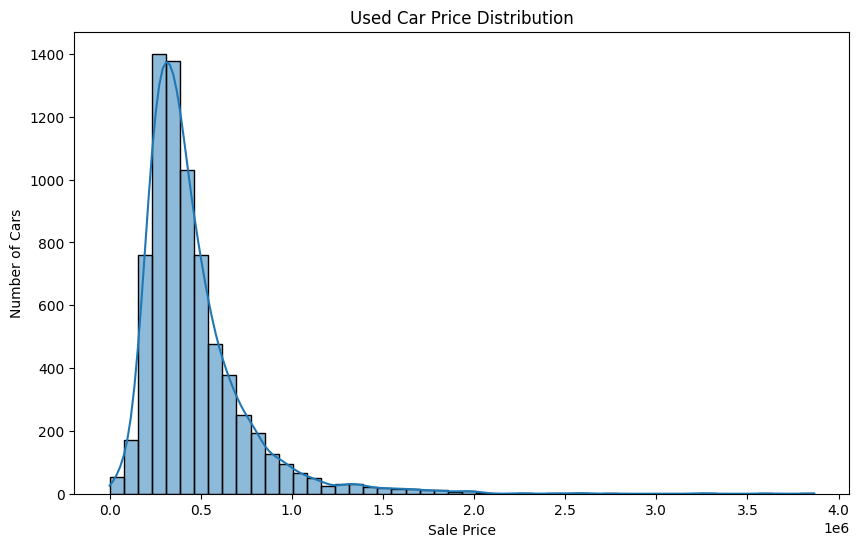

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["sale_price"],
    bins=50,
    kde=True
)

plt.title("Used Car Price Distribution")
plt.xlabel("Sale Price")
plt.ylabel("Number of Cars")

plt.show()

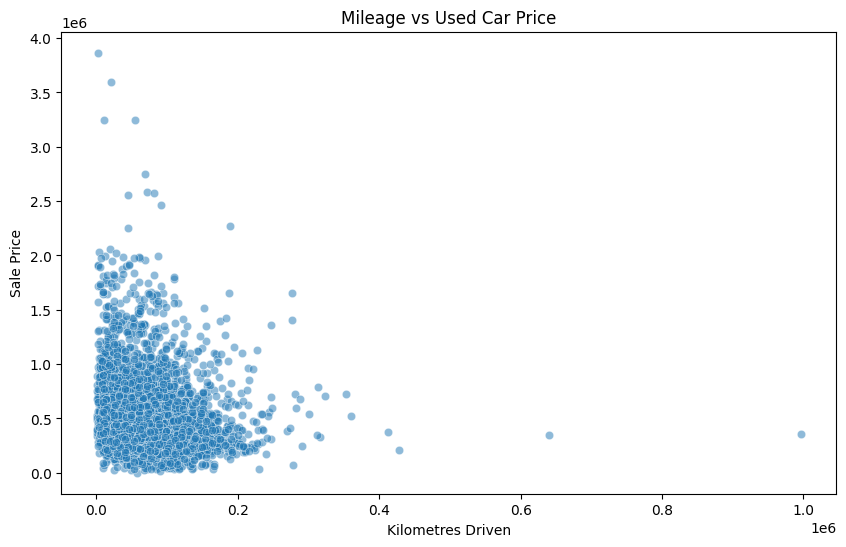

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="kms_run",
    y="sale_price",
    alpha=0.5
)

plt.title("Mileage vs Used Car Price")
plt.xlabel("Kilometres Driven")
plt.ylabel("Sale Price")

plt.show()

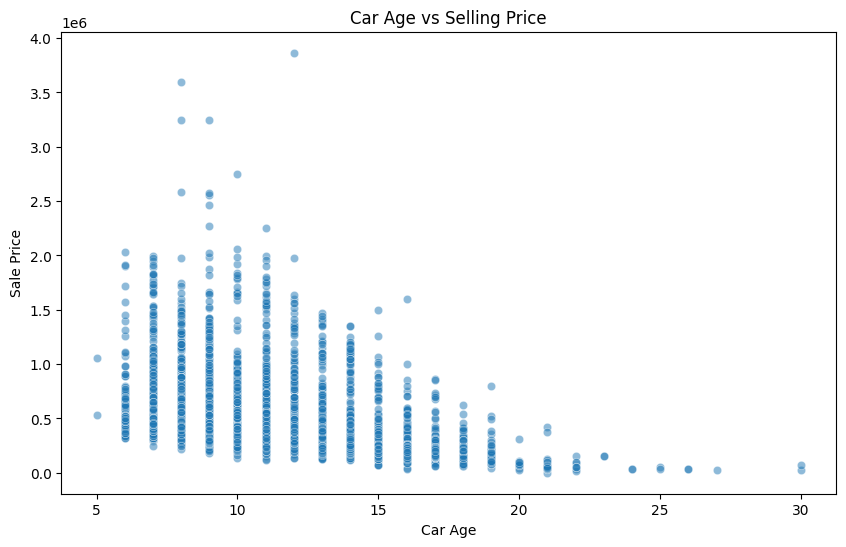

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="car_age",
    y="sale_price",
    alpha=0.5
)

plt.title("Car Age vs Selling Price")
plt.xlabel("Car Age")
plt.ylabel("Sale Price")

plt.show()

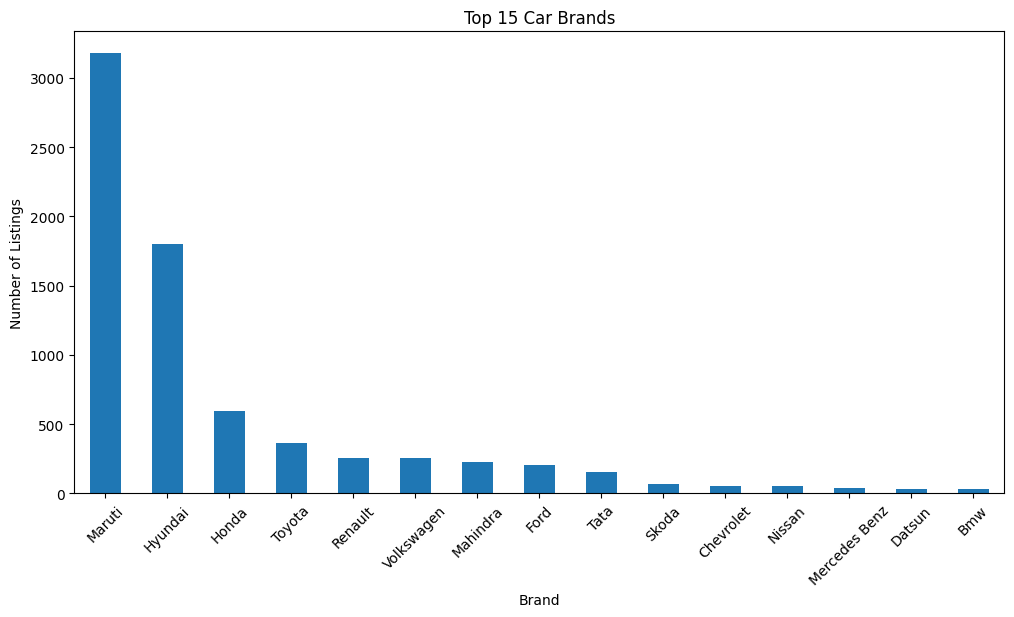

In [ ]:
top_brands = (
    df["make"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(12,6))

top_brands.plot(kind="bar")

plt.title("Top 15 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Listings")

plt.xticks(rotation=45)

plt.show()

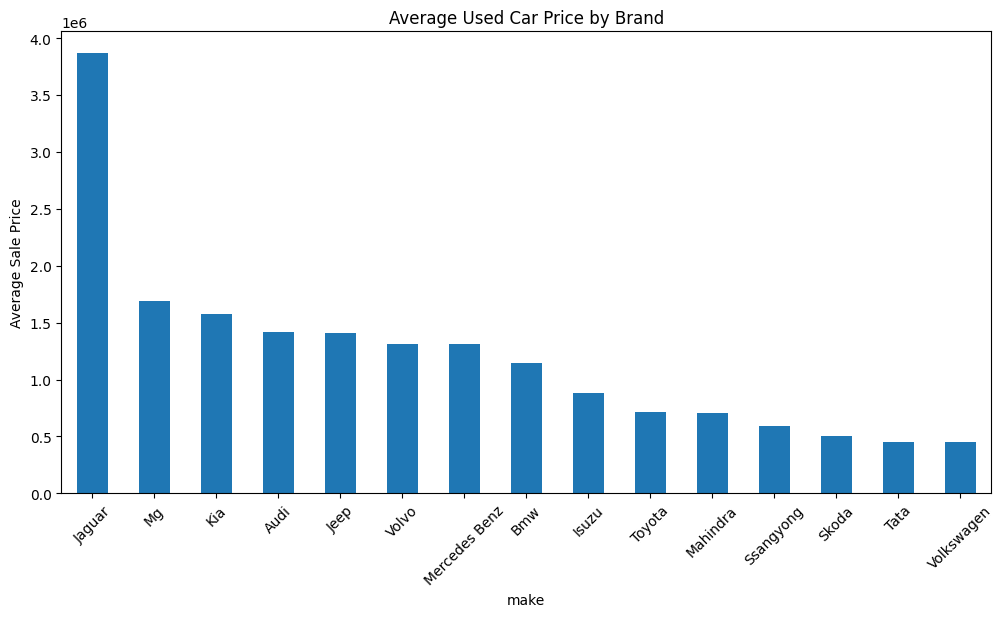

In [ ]:
brand_price = (
    df.groupby("make")["sale_price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))

brand_price.plot(kind="bar")

plt.title("Average Used Car Price by Brand")
plt.ylabel("Average Sale Price")

plt.xticks(rotation=45)

plt.show()

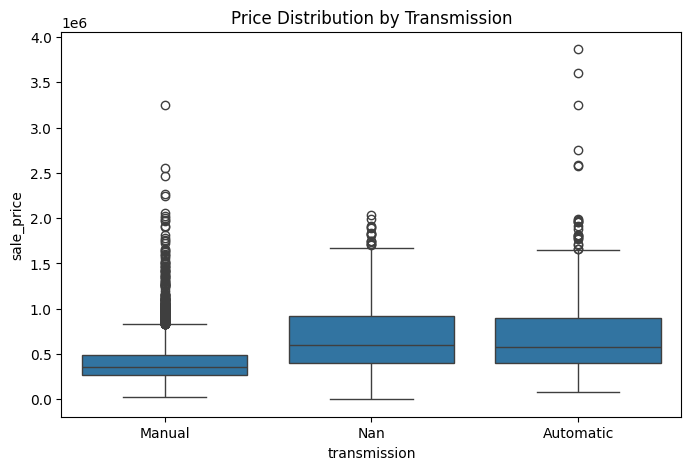

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="transmission",
    y="sale_price"
)

plt.title("Price Distribution by Transmission")

plt.show()

In [ ]:
fuel_analysis = (
    df.groupby("fuel_type")["sale_price"]
    .agg(
        average_price="mean",
        median_price="median",
        listings="count"
    )
    .sort_values(
        "average_price",
        ascending=False
    )
)

print(fuel_analysis)

              average_price  median_price  listings
fuel_type                                          
Diesel        615218.132275      515049.0      2268
Electric      596755.000000      327099.5         6
Petrol        391854.705326      350699.0      4656
Petrol & Cng  312018.821176      302099.0       425
Petrol & Lpg  232435.634146      238599.0        41
